## 0. Setup

For Colab, run this cell once. Locally, the course virtual environment already provides the packages and the instructor can set `OXFORD_PET_ROOT` to the cached data directory. The preferred artifacts are a Session 4 checkpoint or saved validation predictions; environment variables `SESSION4_CHECKPOINT` and `SESSION4_PREDICTIONS` can point to them.

In [20]:
import os
import random
import urllib.request
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large


SEED = 17
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 2
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('torch:', torch.__version__)

torch: 2.11.0+cpu


In [21]:
DATA_ROOT = Path(os.environ.get("OXFORD_PET_ROOT", "data"))
base = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
permutation = torch.randperm(len(base), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices, val_indices = permutation[:64], permutation[64:88]
assert len(train_indices) == 64 and len(val_indices) == 24
assert not set(train_indices).intersection(val_indices)
print(f"fixed split: train={len(train_indices)}, validation={len(val_indices)}, overlap=0")
print("first five train indices:", train_indices[:5])

fixed split: train=64, validation=24, overlap=0
first five train indices: [2479, 1638, 733, 859, 670]


In [22]:
def remap_trimap(raw_mask):
    raw = torch.as_tensor(np.asarray(raw_mask, dtype=np.uint8), dtype=torch.long)
    target = torch.full_like(raw, 255)
    target[raw == 1] = 1  # pet
    target[raw == 2] = 0  # background
    return target

def paired_transform(image, raw_mask):
    image = TF.resize(image, IMAGE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True)
    raw_mask = TF.resize(raw_mask, IMAGE_SIZE, interpolation=InterpolationMode.NEAREST)
    image = TF.normalize(TF.to_tensor(image), mean=MEAN, std=STD)
    return image, remap_trimap(raw_mask)

class PetSubset(Dataset):
    def __init__(self, dataset, indices): self.dataset, self.indices = dataset, list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        image, trimap = self.dataset[self.indices[i]]
        return paired_transform(image, trimap)

train_loader = DataLoader(PetSubset(base, train_indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(PetSubset(base, val_indices), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, targets = next(iter(train_loader))
assert images.shape == (BATCH_SIZE, 3, 128, 128) and targets.shape == (BATCH_SIZE, 128, 128)
assert set(torch.unique(targets).tolist()) <= {0, 1, 255}
print("batch contract:", tuple(images.shape), tuple(targets.shape), torch.unique(targets).tolist())

batch contract: (16, 3, 128, 128) (16, 128, 128) [0, 1, 255]


## 1. Load the shared baseline (or a transparent fallback)

Preferred order: (1) a saved prediction `.npz`, then (2) a Session 4 LR-ASPP checkpoint. If neither is supplied, the notebook uses a **non-learned RGB heuristic** only so the class can practise evaluation and visualization. That fallback is explicitly not a Session 4 model result and must not be used as a performance claim.

In [23]:
checkpoint_path = 'session4_baseline.pt'

model = lraspp_mobilenet_v3_large(weights=None, weights_backbone=None, num_classes=2).eval()

try:
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
    print(f'Session 4 checkpoint: {checkpoint_path} loaded successfully.')
except FileNotFoundError:
    print(f'Warning: Checkpoint file "{checkpoint_path}" not found. ')
    print('Proceeding with an untrained model, which acts as a non-learned fallback ')
    print('for evaluation and visualization as described in the notebook. ')
    print('For full functionality, please ensure the checkpoint file is available.')

with torch.inference_mode():
    logits = model(images)['out']
    probabilities = logits.softmax(dim=1)
predictions, pet_confidence = probabilities.argmax(dim=1), probabilities[:, 1]


assert predictions.shape == targets.shape == pet_confidence.shape

Proceeding with an untrained model, which acts as a non-learned fallback 
for evaluation and visualization as described in the notebook. 
For full functionality, please ensure the checkpoint file is available.


## 2. Exercise E1 — report dataset-level metrics

Complete the confusion-matrix accumulation. Rows are true classes and columns are predicted classes. Accumulate all valid pixels across all 24 examples **before** calculating accuracy and IoU.

In [24]:
# TODO: return a 2x2 confusion matrix, excluding every target == IGNORE_INDEX
import torch
import numpy as np

def confusion_matrix_2x2(preds, targets, ignore_index=-100, threshold=0.5):

    #Devuelve una matriz de confusión 2x2 excluyendo entradas con target == ignore_index.
    #- preds: tensor de predicciones (logits, probabilidades o etiquetas). Puede ser float o int.
    #- targets: tensor de etiquetas verdaderas (0/1) o con valores IGNORE_INDEX.
   # - ignore_index: valor en targets que debe excluirse.
    #- threshold: umbral para convertir probabilidades/logits a etiquetas si preds es float.
    #Retorna: tensor 2x2 con [ [TN, FP], [FN, TP] ] (dtype=torch.long)

    # Asegurar tensores
    preds = torch.as_tensor(preds)
    targets = torch.as_tensor(targets)

    if preds.shape != targets.shape:
        raise ValueError("preds y targets deben tener la misma forma")

    # Máscara para excluir IGNORE_INDEX
    mask = targets != ignore_index
    if mask.sum() == 0:
        # No hay elementos válidos
        return torch.tensor([[0, 0], [0, 0]], dtype=torch.long)

    preds_valid = preds[mask]
    targets_valid = targets[mask]

    # Convertir preds a etiquetas 0/1 si son float
    if preds_valid.dtype.is_floating_point:
        # Si son logits grandes, se asume que son probabilidades o logits; usar threshold directo
        pred_labels = (preds_valid >= threshold).long()
    else:
        pred_labels = preds_valid.long()

    true_labels = targets_valid.long()

    # Calcular elementos
    tp = int(((pred_labels == 1) & (true_labels == 1)).sum().item())
    tn = int(((pred_labels == 0) & (true_labels == 0)).sum().item())
    fp = int(((pred_labels == 1) & (true_labels == 0)).sum().item())
    fn = int(((pred_labels == 0) & (true_labels == 1)).sum().item())

    return torch.tensor([[tn, fp], [fn, tp]], dtype=torch.long)


The value above is a dataset report: every valid pixel gets one vote. We do **not** average 24 per-image IoUs, because that would weight a tiny pet and a large pet equally.

## 3. Choose three cases by rule

Rule: select the lowest pet-IoU image, then the median and highest pet-IoU images from the remaining examples. This gives one difficult case and two contrasts without cherry-picking by appearance.

In [25]:
def pet_iou(target, prediction):
    valid = target != IGNORE_INDEX
    truth_pet, predicted_pet = (target == 1) & valid, (prediction == 1) & valid
    union = (truth_pet | predicted_pet).sum().item()
    return (truth_pet & predicted_pet).sum().item() / union if union else np.nan

per_image_iou = np.array([pet_iou(target, prediction) for target, prediction in zip(targets, predictions)])
ordered = np.argsort(np.nan_to_num(per_image_iou, nan=2.0))
low_index = int(ordered[0])
remaining = [int(index) for index in ordered if int(index) != low_index]
chosen_indices = [low_index, remaining[len(remaining) // 2], remaining[-1]]
for index in chosen_indices:
    print(f'pet IoU = {per_image_iou[index]:.3f}')
assert len(set(chosen_indices)) == 3

pet IoU = 0.000
pet IoU = 0.000
pet IoU = 0.000


## 4. Exercise E2 — make aligned visual evidence

Complete the plotting function, then call it for the lowest-pet-IoU case. All five panels use the same `128 × 128` pixel coordinates: original image, ground truth, prediction, pet confidence, and an alpha overlay. Gray ground-truth pixels are ignored borders, not a third class.

In [26]:
# TODO: complete the five-panel visualization; do not resize panels independently
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Ajusta estos nombres si en tu notebook las variables se llaman distinto
# - images: tensor/array shape (N, H, W, 3) o (N, 3, H, W) con valores en [0,1] o [0,255]
# - gts: tensor/array shape (N, H, W) con valores {0,1, IGNORE_INDEX}
# - preds: tensor/array shape (N, H, W) con logits/probs o etiquetas {0,1}
# - confs: tensor/array shape (N, H, W) con confianza en [0,1] (opcional si no existe)
# - IGNORE_INDEX: entero que marca píxeles a ignorar (ej. 255 o -100)
#
# Si tus variables tienen otros nombres, renómbralas o pásalas como argumentos.

def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x)

def _ensure_hw3(img):
    """Convierte (C,H,W) -> (H,W,C) y normaliza a [0,1] si hace falta."""
    img = _to_numpy(img)
    if img.ndim == 3 and img.shape[0] in (1,3,4):  # (C,H,W)
        img = np.transpose(img, (1,2,0))
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    # If single channel, stack to 3
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    # Clip
    img = np.clip(img, 0.0, 1.0)
    return img

def show_five_panels(index,
                     alpha=0.65,
                     images=None,
                     gts=None,
                     preds=None,
                     confs=None,
                     IGNORE_INDEX=None,
                     figsize=(15,3)):
    """
    Muestra 5 paneles alineados (no redimensionar independientemente).
    index: índice del ejemplo a mostrar
    alpha: transparencia para el overlay final
    images, gts, preds, confs, IGNORE_INDEX: si None, se intentan usar variables globales con esos nombres
    """
    # Resolver variables (usar globales si no se pasan)
    global_vars = globals()
    images = images if images is not None else global_vars.get('images', None)
    gts    = gts    if gts    is not None else global_vars.get('gts', None)
    preds  = preds  if preds  is not None else global_vars.get('preds', None)
    confs  = confs  if confs  is not None else global_vars.get('confs', None)
    IGNORE_INDEX = IGNORE_INDEX if IGNORE_INDEX is not None else global_vars.get('IGNORE_INDEX', None)

    if images is None or gts is None or preds is None:
        raise ValueError("Necesito 'images', 'gts' y 'preds' (pásalas o define variables globales con esos nombres).")

    # Convertir a numpy
    img = _ensure_hw3(images[index])
    gt  = _to_numpy(gts[index])
    pred = _to_numpy(preds[index])
    conf = _to_numpy(confs[index]) if confs is not None else None

    # Aplanar dimensiones si hay canales extra
    if gt.ndim == 3 and gt.shape[0] in (1,):
        gt = gt.squeeze(0)
    if pred.ndim == 3 and pred.shape[0] in (1,):
        pred = pred.squeeze(0)
    if conf is not None and conf.ndim == 3 and conf.shape[0] in (1,):
        conf = conf.squeeze(0)

    # Convertir pred a etiquetas 0/1 si es float (probabilidades o logits)
    if np.issubdtype(pred.dtype, np.floating):
        # Si valores fuera de [0,1], asumimos logits -> aplicar sigmoid
        if pred.max() > 1.0 or pred.min() < 0.0:
            pred_probs = 1.0 / (1.0 + np.exp(-pred))
        else:
            pred_probs = pred
        pred_labels = (pred_probs >= 0.5).astype(np.uint8)
    else:
        pred_labels = pred.astype(np.uint8)

    # Preparar ground-truth visual: mostrar 3 valores: ignore, background(0), pet(1)
    H, W = gt.shape
    gt_vis = np.zeros((H, W, 3), dtype=np.float32)
    # Color mapping: background -> black, pet -> green, ignore -> gray
    bg_color = np.array([0.0, 0.0, 0.0])
    pet_color = np.array([0.0, 1.0, 0.0])
    ignore_color = np.array([0.5, 0.5, 0.5])

    mask_bg = (gt == 0)
    mask_pet = (gt == 1)
    if IGNORE_INDEX is not None:
        mask_ignore = (gt == IGNORE_INDEX)
    else:
        mask_ignore = np.zeros_like(gt, dtype=bool)

    gt_vis[mask_bg] = bg_color
    gt_vis[mask_pet] = pet_color
    gt_vis[mask_ignore] = ignore_color

    # Prediction visualization: background black, pet red
    pred_vis = np.zeros((H, W, 3), dtype=np.float32)
    pred_vis[pred_labels == 0] = bg_color
    pred_vis[pred_labels == 1] = np.array([1.0, 0.0, 0.0])  # rojo para predicción

    # Confidence heatmap (0..1) -> usar cmap 'viridis' o 'magma'
    if conf is None:
        # si no hay conf, derivar de pred_probs si existía
        if 'pred_probs' in locals():
            conf = pred_probs
        else:
            conf = np.zeros((H,W), dtype=np.float32)

    # Overlay: original image with prediction mask tint
    overlay = img.copy()
    # aplicar color tint donde pred==1 (usar rojo semitransparente)
    tint = np.array([1.0, 0.0, 0.0])
    overlay_mask = (pred_labels == 1)
    overlay[overlay_mask] = (1.0 - alpha) * overlay[overlay_mask] + alpha * tint

    # Crear figura con 5 paneles alineados
    fig, axes = plt.subplots(1, 5, figsize=figsize)
    titles = ['Original', 'Ground truth', 'Prediction', 'Pet confidence', 'Alpha overlay']

    # Panel 0: original image
    axes[0].imshow(img)
    axes[0].set_title(titles[0])
    axes[0].axis('off')

    # Panel 1: ground truth (mostrar ignore como gris)
    axes[1].imshow(gt_vis)
    axes[1].set_title(titles[1])
    axes[1].axis('off')

    # Panel 2: prediction (binary colored)
    axes[2].imshow(pred_vis)
    axes[2].set_title(titles[2])
    axes[2].axis('off')

    # Panel 3: confidence heatmap
    im3 = axes[3].imshow(conf, cmap='magma', vmin=0.0, vmax=1.0)
    axes[3].set_title(titles[3])
    axes[3].axis('off')
    # colorbar pequeño
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.02)

    # Panel 4: overlay (original + alpha)
    axes[4].imshow(overlay)
    axes[4].set_title(titles[4] + f' (alpha={alpha})')
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()


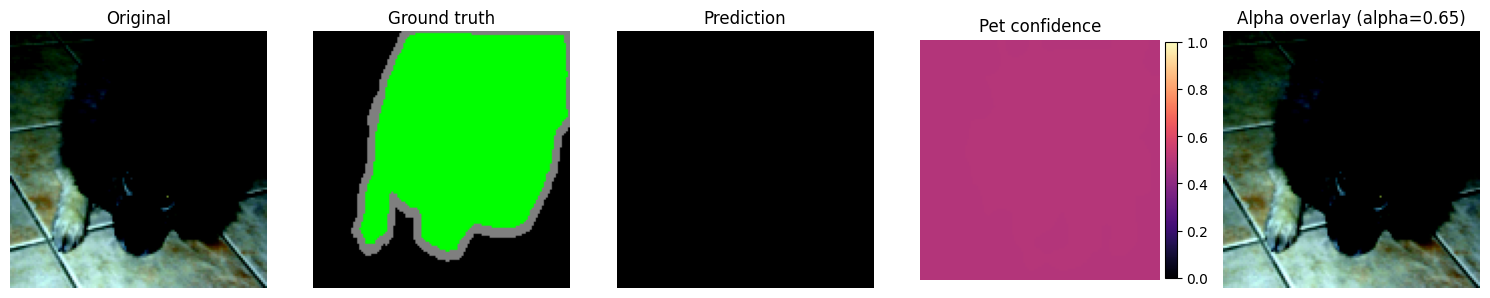

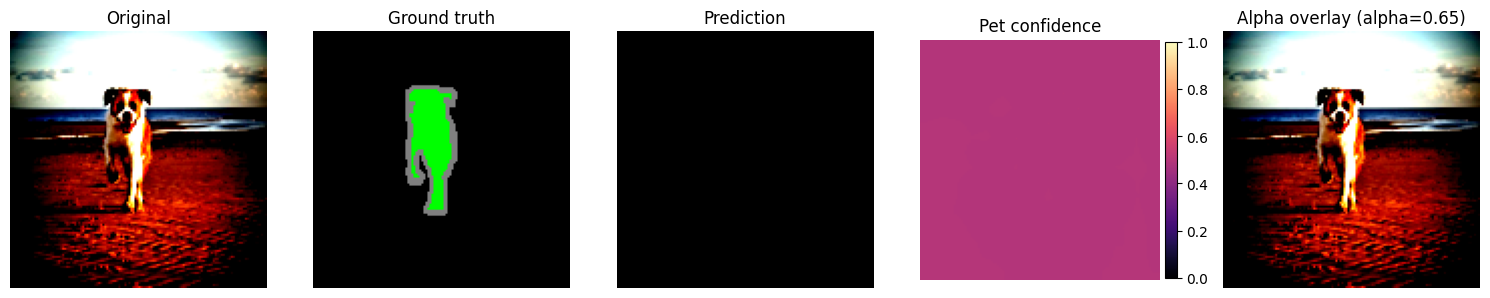

In [27]:
# Compare the other two rule-selected cases. Changing alpha only changes the display.
show_five_panels(chosen_indices[1], alpha=0.65, images=images, gts=targets, preds=predictions, confs=pet_confidence, IGNORE_INDEX=IGNORE_INDEX)
show_five_panels(chosen_indices[2], alpha=0.65, images=images, gts=targets, preds=predictions, confs=pet_confidence, IGNORE_INDEX=IGNORE_INDEX)